# Notebook 04: Model Experiments

**Objective**: Train and evaluate multi-task age-gender CNN models with different hyperparameter configurations.

**Experiments**:
1. **Baseline**: Default hyperparameters (lr=1e-4, full augmentation, loss weights=1.0/1.0)
2. **Age-Focused**: Increased age loss weight (2.0) to prioritize age performance
3. **Conservative Learning**: Reduced learning rate (5e-5) for more stable convergence
4. **Minimal Augmentation**: Only horizontal flip to test overfitting

**Implementation Checklist Mapping**:
- ✅ Phase 3: Model Architecture
- ✅ Phase 4: Training Loop
- ✅ Phase 5: Hyperparameter Tuning

## Setup

In [1]:
# Install dependencies
%pip install -q torch torchvision numpy pandas scikit-learn albumentations opencv-python matplotlib seaborn tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from sklearn.model_selection import train_test_split

import torch
import torch.optim as optim
from torch.utils.data import DataLoader

# Add src to path
def find_project_root():
    current = Path.cwd()
    while current != current.parent:
        if (current / 'src').exists():
            return current
        current = current.parent
    return Path.cwd()

project_root = find_project_root()
sys.path.insert(0, str(project_root / 'src'))

# Import project modules
from data.load_utkface import UTKFaceDataset
from data.preprocessing import (
    get_train_transforms,
    get_inference_transforms,
    get_minimal_augmentation_transforms
)
from models.multitask_model import AgeGenderModel
from models.losses import MultiTaskLoss
from training.train import train_one_epoch
from training.validate import validate
from training.evaluate import evaluate_model
from utils.config import ExperimentConfig, save_experiment_results
from utils.visualization import plot_training_history

print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Project root: c:\Users\Mark\Projects\age-gender-cnn
PyTorch version: 2.5.1+cu121
CUDA available: True


In [3]:
# Constants
SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set random seeds for reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

print(f"Using device: {DEVICE}")
print(f"Random seed: {SEED}")

Using device: cuda
Random seed: 42


## Data Preparation

In [4]:
# Load metadata (generated by notebook 01)
PROCESSED_ROOT = project_root / 'dataset' / 'processed'
image_dir = project_root / 'dataset' / 'raw' / 'UTKFace'

# Look for any metadata file with timestamp pattern
metadata_candidates = sorted(PROCESSED_ROOT.glob("utkface_metadata_*.csv"))
if not metadata_candidates:
    raise FileNotFoundError(
        f"No metadata CSV found in {PROCESSED_ROOT}.\n"
        "Please run notebook 01_dataset_exploration.ipynb first to generate metadata."
    )

# Use the most recent metadata file
metadata_path = metadata_candidates[-1]
print(f"Using metadata: {metadata_path.name}")

metadata = pd.read_csv(metadata_path)
print(f"Loaded {len(metadata)} samples from metadata")
print(f"\nMetadata columns: {metadata.columns.tolist()}")
print(f"\nFirst few rows:")
display(metadata.head())

Using metadata: utkface_metadata_20260222T151110Z.csv
Loaded 47812 samples from metadata

Metadata columns: ['path', 'relative_path', 'folder', 'filename', 'age', 'gender', 'ethnicity', 'adience_bin', 'size_bytes', 'parse_status', 'parse_reason']

First few rows:


,path,relative_path,folder,filename,age,gender,ethnicity,adience_bin,size_bytes,parse_status,parse_reason
0,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,dataset\raw\UTKFace\100_0_0_20170112213500903.jpg,.,100_0_0_20170112213500903.jpg,100.0,0.0,0.0,60+,97833,valid,ok
1,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,dataset\raw\UTKFace\100_0_0_20170112213500903....,.,100_0_0_20170112213500903.jpg.chip.jpg,100.0,0.0,0.0,60+,7916,valid,ok
2,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,dataset\raw\UTKFace\100_0_0_20170112215240346.jpg,.,100_0_0_20170112215240346.jpg,100.0,0.0,0.0,60+,108750,valid,ok
3,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,dataset\raw\UTKFace\100_0_0_20170112215240346....,.,100_0_0_20170112215240346.jpg.chip.jpg,100.0,0.0,0.0,60+,7208,valid,ok
4,C:\Users\Mark\Projects\age-gender-cnn\dataset\...,dataset\raw\UTKFace\100_1_0_20170110183726390.jpg,.,100_1_0_20170110183726390.jpg,100.0,1.0,0.0,60+,60132,valid,ok


In [5]:
# Create stratified splits (70/15/15)
# Stratify by gender and broad age bands to ensure balanced distribution

def create_age_bands(ages):
    """Create broad age bands for stratification."""
    bands = []
    for age in ages:
        if age <= 20:
            bands.append('0-20')
        elif age <= 40:
            bands.append('21-40')
        elif age <= 60:
            bands.append('41-60')
        else:
            bands.append('61+')
    return bands

# Create stratification variable (gender + age band)
metadata['age_band'] = create_age_bands(metadata['age'].values)
metadata['stratify_key'] = metadata['gender'].astype(str) + '_' + metadata['age_band']

# Split: 70% train, 15% val, 15% test
train_idx, temp_idx = train_test_split(
    np.arange(len(metadata)),
    test_size=0.30,
    stratify=metadata['stratify_key'],
    random_state=SEED
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=metadata.iloc[temp_idx]['stratify_key'],
    random_state=SEED
)

print(f"Split sizes:")
print(f"  Train: {len(train_idx)} ({len(train_idx)/len(metadata)*100:.1f}%)")
print(f"  Val:   {len(val_idx)} ({len(val_idx)/len(metadata)*100:.1f}%)")
print(f"  Test:  {len(test_idx)} ({len(test_idx)/len(metadata)*100:.1f}%)")

# Save splits for reproducibility
splits_path = project_root / 'dataset' / 'processed' / 'utkface_splits.json'
splits_path.parent.mkdir(parents=True, exist_ok=True)

splits_data = {
    'train': train_idx.tolist(),
    'val': val_idx.tolist(),
    'test': test_idx.tolist(),
    'random_seed': SEED,
    'created_at': datetime.now().isoformat()
}

with open(splits_path, 'w') as f:
    json.dump(splits_data, f, indent=2)

print(f"\nSaved splits to {splits_path}")

Split sizes:
  Train: 33468 (70.0%)
  Val:   7172 (15.0%)
  Test:  7172 (15.0%)

Saved splits to c:\Users\Mark\Projects\age-gender-cnn\dataset\processed\utkface_splits.json


In [6]:
# Verify stratification
print("Train set distribution:")
print(metadata.iloc[train_idx]['stratify_key'].value_counts().sort_index())

print("\nValidation set distribution:")
print(metadata.iloc[val_idx]['stratify_key'].value_counts().sort_index())

print("\nTest set distribution:")
print(metadata.iloc[test_idx]['stratify_key'].value_counts().sort_index())

Train set distribution:
stratify_key
0.0_0-20     3207
0.0_21-40    8111
0.0_41-60    4206
0.0_61+      1956
1.0_0-20     3829
1.0_21-40    8881
1.0_41-60    1842
1.0_61+      1436
Name: count, dtype: int64

Validation set distribution:
stratify_key
0.0_0-20      687
0.0_21-40    1738
0.0_41-60     901
0.0_61+       420
1.0_0-20      820
1.0_21-40    1903
1.0_41-60     395
1.0_61+       308
Name: count, dtype: int64

Test set distribution:
stratify_key
0.0_0-20      687
0.0_21-40    1739
0.0_41-60     901
0.0_61+       419
1.0_0-20      821
1.0_21-40    1903
1.0_41-60     394
1.0_61+       308
Name: count, dtype: int64


## Helper Function: Training Pipeline

In [7]:
def run_experiment(config: ExperimentConfig):
    """
    Run complete training experiment with given configuration.
    
    Returns:
        Tuple of (model, history, best_val_loss)
    """
    print(f"\n{'='*60}")
    print(f"Experiment: {config.experiment_id}")
    print(f"Description: {config.description}")
    print(f"{'='*60}\n")
    
    # Create data transforms based on config
    if config.augmentation == 'full':
        train_transform = get_train_transforms()
        print("Using FULL augmentation")
    elif config.augmentation == 'minimal':
        train_transform = get_minimal_augmentation_transforms()
        print("Using MINIMAL augmentation")
    else:
        train_transform = get_inference_transforms()
        print("Using NO augmentation")
    
    val_transform = get_inference_transforms()
    
    # Create datasets
    train_dataset = UTKFaceDataset(
        metadata_path=str(metadata_path),
        image_dir=str(image_dir),
        split_indices=train_idx.tolist(),
        transform=train_transform
    )
    
    val_dataset = UTKFaceDataset(
        metadata_path=str(metadata_path),
        image_dir=str(image_dir),
        split_indices=val_idx.tolist(),
        transform=val_transform
    )
    
    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )
    
    print(f"Train batches: {len(train_loader)}")
    print(f"Val batches: {len(val_loader)}")
    
    # Create model
    model = AgeGenderModel(
        pretrained_backbone=config.pretrained_backbone,
        freeze_backbone=config.freeze_backbone,
        dropout_rate=config.dropout_rate
    ).to(DEVICE)
    
    print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    
    # Create optimizer and loss function
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
    loss_fn = MultiTaskLoss(
        age_weight=config.age_loss_weight,
        gender_weight=config.gender_loss_weight
    )
    
    print(f"\nOptimizer: {config.optimizer}")
    print(f"Learning rate: {config.learning_rate}")
    print(f"Loss weights: age={config.age_loss_weight}, gender={config.gender_loss_weight}")
    
    # Training loop
    history = {
        'train_total': [],
        'train_age': [],
        'train_gender': [],
        'val_total': [],
        'val_age': [],
        'val_gender': []
    }
    
    best_val_loss = float('inf')
    best_epoch = 0
    
    checkpoint_dir = project_root / config.checkpoint_dir
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = checkpoint_dir / f"{config.experiment_id}_best.pth"
    
    print(f"\nStarting training for {config.num_epochs} epochs...\n")
    
    for epoch in range(1, config.num_epochs + 1):
        # Train
        train_losses = train_one_epoch(
            model, train_loader, optimizer, loss_fn, DEVICE, epoch
        )
        
        # Validate
        val_losses = validate(model, val_loader, loss_fn, DEVICE)
        
        # Record history
        history['train_total'].append(train_losses['total'])
        history['train_age'].append(train_losses['age'])
        history['train_gender'].append(train_losses['gender'])
        history['val_total'].append(val_losses['total'])
        history['val_age'].append(val_losses['age'])
        history['val_gender'].append(val_losses['gender'])
        
        # Print epoch summary
        print(f"\nEpoch {epoch}/{config.num_epochs}:")
        print(f"  Train - Total: {train_losses['total']:.4f}, Age: {train_losses['age']:.4f}, Gender: {train_losses['gender']:.4f}")
        print(f"  Val   - Total: {val_losses['total']:.4f}, Age: {val_losses['age']:.4f}, Gender: {val_losses['gender']:.4f}")
        
        # Save best model
        if val_losses['total'] < best_val_loss:
            best_val_loss = val_losses['total']
            best_epoch = epoch
            
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': best_val_loss,
                'config': config.to_dict()
            }
            
            torch.save(checkpoint, checkpoint_path)
            print(f"  *** New best model saved (val_loss: {best_val_loss:.4f}) ***")
    
    print(f"\nTraining complete!")
    print(f"Best validation loss: {best_val_loss:.4f} at epoch {best_epoch}")
    print(f"Model checkpoint saved to: {checkpoint_path}")
    
    # Load best model
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    return model, history, best_val_loss

## Experiment 1: Baseline

Default configuration:
- Learning rate: 1e-4
- Batch size: 32
- Epochs: 20
- Loss weights: 1.0 / 1.0
- Augmentation: Full

In [8]:
# Create baseline configuration
baseline_config = ExperimentConfig(
    experiment_id="exp01_baseline",
    description="Baseline model with default hyperparameters",
    learning_rate=1e-4,
    batch_size=32,
    num_epochs=20,
    age_loss_weight=1.0,
    gender_loss_weight=1.0,
    augmentation="full",
    random_seed=SEED,
    device=str(DEVICE)
)

run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
# Save config
config_path = project_root / 'experiments' / f"{baseline_config.experiment_id}_config_{run_id}.json"
baseline_config.to_json(str(config_path))

# Run experiment
baseline_model, baseline_history, baseline_best_loss = run_experiment(baseline_config)

Saved config to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp01_baseline_config_20260222T154758Z.json

Experiment: exp01_baseline
Description: Baseline model with default hyperparameters

Using FULL augmentation
Train batches: 1046
Val batches: 225

Model parameters: 3,751,018
Trainable parameters: 3,751,018

Optimizer: Adam
Learning rate: 0.0001
Loss weights: age=1.0, gender=1.0

Starting training for 20 epochs...



Validation: 100%|██████████| 225/225 [00:48<00:00,  4.63it/s, val_loss=8.8312, age=8.2225, gender=0.6087] 



Epoch 1/20:
  Train - Total: 9.6170, Age: 9.2456, Gender: 0.3714
  Val   - Total: 6.6494, Age: 6.3632, Gender: 0.2861
  *** New best model saved (val_loss: 6.6494) ***


Validation: 100%|██████████| 225/225 [00:22<00:00, 10.10it/s, val_loss=12.5476, age=12.1655, gender=0.3822]



Epoch 2/20:
  Train - Total: 7.1803, Age: 6.8886, Gender: 0.2917
  Val   - Total: 6.5892, Age: 6.3237, Gender: 0.2656
  *** New best model saved (val_loss: 6.5892) ***


...

Validation: 100%|██████████| 225/225 [00:20<00:00, 11.09it/s, val_loss=8.6725, age=7.6876, gender=0.9849]



Epoch 19/20:
  Train - Total: 4.4572, Age: 4.2898, Gender: 0.1674
  Val   - Total: 5.2888, Age: 5.0796, Gender: 0.2092


Validation: 100%|██████████| 225/225 [00:20<00:00, 11.08it/s, val_loss=8.4081, age=7.7278, gender=0.6803]


Epoch 20/20:
  Train - Total: 4.4177, Age: 4.2513, Gender: 0.1664
  Val   - Total: 5.1960, Age: 4.9924, Gender: 0.2036

Training complete!
Best validation loss: 5.1558 at epoch 18
Model checkpoint saved to: c:\Users\Mark\Projects\age-gender-cnn\models\exp01_baseline_best.pth



C:\Users\Mark\AppData\Local\Temp\ipykernel_26088\1550990232.py:144: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


Saved training history plot to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp01_baseline_history_20260222T154758Z.png


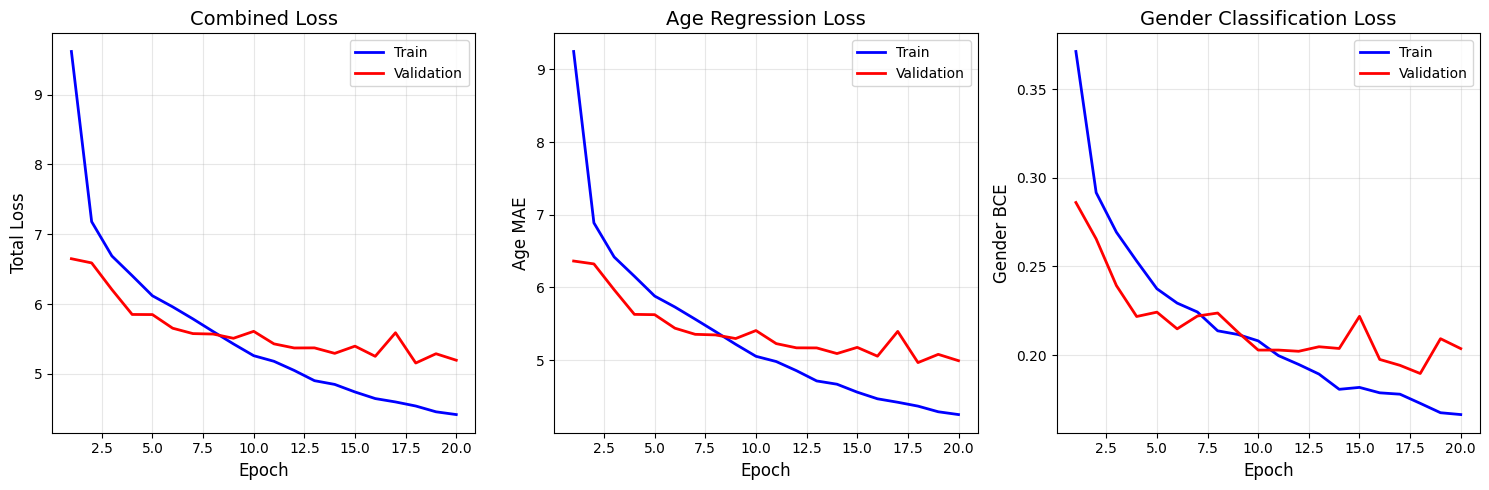

In [9]:
# Plot training history
plot_training_history(
    baseline_history,
    save_path=str(project_root / 'experiments' / f"{baseline_config.experiment_id}_history_{run_id}.png")
)

In [10]:
# Evaluate on validation set
val_dataset = UTKFaceDataset(
    metadata_path=str(metadata_path),
    image_dir=str(image_dir),
    split_indices=val_idx.tolist(),
    transform=get_inference_transforms()
)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

age_preds, gender_preds, age_targets, gender_targets, metrics = evaluate_model(
    baseline_model, val_loader, DEVICE
)

# Save results
save_experiment_results(
    baseline_config,
    metrics,
    baseline_history,
    str(project_root / 'experiments' / f"{baseline_config.experiment_id}_results_{run_id}.json")
)

Evaluating: 100%|██████████| 225/225 [00:32<00:00,  6.91it/s]


Evaluation Results:
  Age MAE: 4.95 years
  Gender Accuracy: 0.9267 (92.67%)
Saved experiment results to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp01_baseline_results_20260222T154758Z.json


## Experiment 2: Age-Focused (Increased Age Loss Weight)

Test if prioritizing age loss improves age prediction performance:
- Age loss weight: 2.0
- Gender loss weight: 1.0
- Other settings: Same as baseline

In [11]:
age_focused_config = ExperimentConfig(
    experiment_id="exp02_age_focused",
    description="Increased age loss weight to prioritize age performance",
    learning_rate=1e-4,
    batch_size=32,
    num_epochs=20,
    age_loss_weight=2.0,
    gender_loss_weight=1.0,
    augmentation="full",
    random_seed=SEED,
    device=str(DEVICE)
)

age_focused_config.to_json(str(project_root / 'experiments' / f"{age_focused_config.experiment_id}_config_{run_id}.json"))
age_focused_model, age_focused_history, age_focused_best_loss = run_experiment(age_focused_config)

Saved config to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp02_age_focused_config_20260222T154758Z.json

Experiment: exp02_age_focused
Description: Increased age loss weight to prioritize age performance

Using FULL augmentation
Train batches: 1046
Val batches: 225

Model parameters: 3,751,018
Trainable parameters: 3,751,018

Optimizer: Adam
Learning rate: 0.0001
Loss weights: age=2.0, gender=1.0

Starting training for 20 epochs...



Validation: 100%|██████████| 225/225 [00:20<00:00, 11.22it/s, val_loss=12.5064, age=6.0813, gender=0.3437]



Epoch 1/20:
  Train - Total: 19.3549, Age: 9.4697, Gender: 0.4155
  Val   - Total: 13.3664, Age: 6.5250, Gender: 0.3164
  *** New best model saved (val_loss: 13.3664) ***


Validation: 100%|██████████| 225/225 [00:20<00:00, 11.15it/s, val_loss=11.0037, age=5.4169, gender=0.1698]



Epoch 2/20:
  Train - Total: 14.2359, Age: 6.9548, Gender: 0.3263
  Val   - Total: 12.2502, Age: 5.9772, Gender: 0.2957
  *** New best model saved (val_loss: 12.2502) ***


...

Validation: 100%|██████████| 225/225 [00:19<00:00, 11.26it/s, val_loss=26.0365, age=12.6229, gender=0.7908]



Epoch 19/20:
  Train - Total: 9.0829, Age: 4.4351, Gender: 0.2126
  Val   - Total: 10.4103, Age: 5.0946, Gender: 0.2210


Validation: 100%|██████████| 225/225 [00:20<00:00, 11.22it/s, val_loss=21.6226, age=10.5754, gender=0.4719]


Epoch 20/20:
  Train - Total: 8.9695, Age: 4.3807, Gender: 0.2082
  Val   - Total: 10.2798, Age: 5.0339, Gender: 0.2121
  *** New best model saved (val_loss: 10.2798) ***

Training complete!
Best validation loss: 10.2798 at epoch 20
Model checkpoint saved to: c:\Users\Mark\Projects\age-gender-cnn\models\exp02_age_focused_best.pth



C:\Users\Mark\AppData\Local\Temp\ipykernel_26088\1550990232.py:144: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


Saved training history plot to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp02_age_focused_history_20260222T154758Z.png


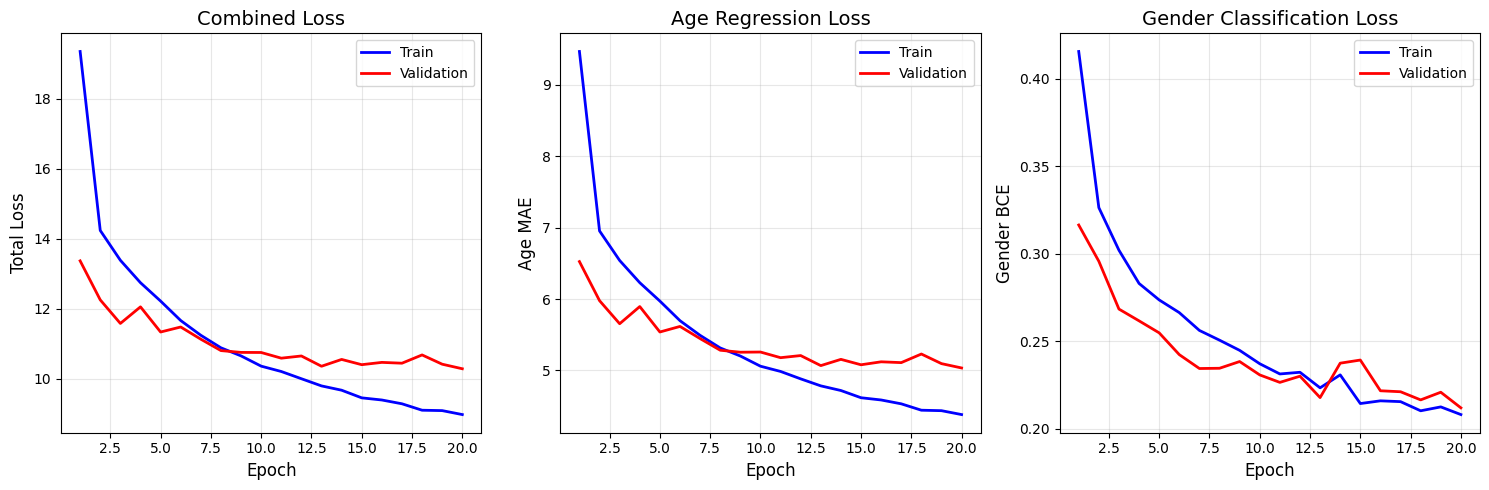

Evaluating: 100%|██████████| 225/225 [00:31<00:00,  7.11it/s]


Evaluation Results:
  Age MAE: 5.01 years
  Gender Accuracy: 0.9137 (91.37%)
Saved experiment results to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp02_age_focused_results_20260222T154758Z.json


In [12]:
plot_training_history(
    age_focused_history,
    save_path=str(project_root / 'experiments' / f"{age_focused_config.experiment_id}_history_{run_id}.png")
)

age_preds, gender_preds, age_targets, gender_targets, metrics = evaluate_model(
    age_focused_model, val_loader, DEVICE
)

save_experiment_results(
    age_focused_config,
    metrics,
    age_focused_history,
    str(project_root / 'experiments' / f"{age_focused_config.experiment_id}_results_{run_id}.json")
)

## Experiment 3: Conservative Learning (Reduced Learning Rate)

Test if slower learning provides better convergence:
- Learning rate: 5e-5
- Other settings: Same as baseline

In [13]:
conservative_config = ExperimentConfig(
    experiment_id="exp03_conservative_lr",
    description="Reduced learning rate for more stable convergence",
    learning_rate=5e-5,
    batch_size=32,
    num_epochs=20,
    age_loss_weight=1.0,
    gender_loss_weight=1.0,
    augmentation="full",
    random_seed=SEED,
    device=str(DEVICE)
)

conservative_config.to_json(str(project_root / 'experiments' / f"{conservative_config.experiment_id}_config_{run_id}.json"))
conservative_model, conservative_history, conservative_best_loss = run_experiment(conservative_config)

Saved config to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp03_conservative_lr_config_20260222T154758Z.json

Experiment: exp03_conservative_lr
Description: Reduced learning rate for more stable convergence

Using FULL augmentation
Train batches: 1046
Val batches: 225

Model parameters: 3,751,018
Trainable parameters: 3,751,018

Optimizer: Adam
Learning rate: 5e-05
Loss weights: age=1.0, gender=1.0

Starting training for 20 epochs...



Validation: 100%|██████████| 225/225 [00:19<00:00, 11.26it/s, val_loss=4.2123, age=3.8668, gender=0.3456]



Epoch 1/20:
  Train - Total: 10.7414, Age: 10.3532, Gender: 0.3883
  Val   - Total: 7.1703, Age: 6.8757, Gender: 0.2947
  *** New best model saved (val_loss: 7.1703) ***


Validation: 100%|██████████| 225/225 [00:20<00:00, 10.88it/s, val_loss=5.6386, age=5.4026, gender=0.2360] 



Epoch 2/20:
  Train - Total: 7.3387, Age: 7.0353, Gender: 0.3034
  Val   - Total: 6.3239, Age: 6.0580, Gender: 0.2659
  *** New best model saved (val_loss: 6.3239) ***


...

Validation: 100%|██████████| 225/225 [00:19<00:00, 11.30it/s, val_loss=11.2326, age=11.0055, gender=0.2270]



Epoch 19/20:
  Train - Total: 4.5994, Age: 4.4213, Gender: 0.1781
  Val   - Total: 5.3189, Age: 5.1136, Gender: 0.2053


Validation: 100%|██████████| 225/225 [00:20<00:00, 11.18it/s, val_loss=9.5167, age=9.2125, gender=0.3043]


Epoch 20/20:
  Train - Total: 4.4445, Age: 4.2745, Gender: 0.1700
  Val   - Total: 5.4171, Age: 5.2173, Gender: 0.1999

Training complete!
Best validation loss: 5.3097 at epoch 16
Model checkpoint saved to: c:\Users\Mark\Projects\age-gender-cnn\models\exp03_conservative_lr_best.pth



C:\Users\Mark\AppData\Local\Temp\ipykernel_26088\1550990232.py:144: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


Saved training history plot to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp03_conservative_lr_history_20260222T154758Z.png


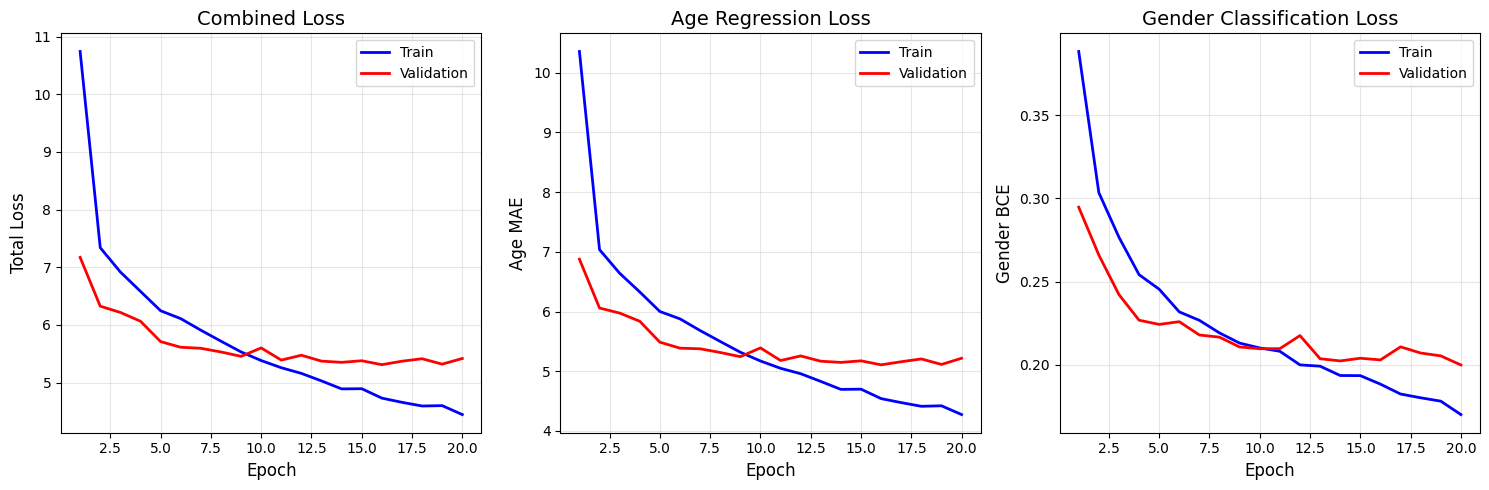

Evaluating: 100%|██████████| 225/225 [00:32<00:00,  6.90it/s]


Evaluation Results:
  Age MAE: 5.10 years
  Gender Accuracy: 0.9179 (91.79%)
Saved experiment results to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp03_conservative_lr_results_20260222T154758Z.json


In [14]:
plot_training_history(
    conservative_history,
    save_path=str(project_root / 'experiments' / f"{conservative_config.experiment_id}_history_{run_id}.png")
)

age_preds, gender_preds, age_targets, gender_targets, metrics = evaluate_model(
    conservative_model, val_loader, DEVICE
)

save_experiment_results(
    conservative_config,
    metrics,
    conservative_history,
    str(project_root / 'experiments' / f"{conservative_config.experiment_id}_results_{run_id}.json")
)

## Experiment 4: Minimal Augmentation

Test overfitting with reduced augmentation:
- Augmentation: Minimal (only horizontal flip)
- Other settings: Same as baseline

In [15]:
minimal_aug_config = ExperimentConfig(
    experiment_id="exp04_minimal_aug",
    description="Minimal augmentation to test overfitting",
    learning_rate=1e-4,
    batch_size=32,
    num_epochs=20,
    age_loss_weight=1.0,
    gender_loss_weight=1.0,
    augmentation="minimal",
    random_seed=SEED,
    device=str(DEVICE)
)

minimal_aug_config.to_json(str(project_root / 'experiments' / f"{minimal_aug_config.experiment_id}_config_{run_id}.json"))
minimal_aug_model, minimal_aug_history, minimal_aug_best_loss = run_experiment(minimal_aug_config)

Saved config to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp04_minimal_aug_config_20260222T154758Z.json

Experiment: exp04_minimal_aug
Description: Minimal augmentation to test overfitting

Using MINIMAL augmentation
Train batches: 1046
Val batches: 225

Model parameters: 3,751,018
Trainable parameters: 3,751,018

Optimizer: Adam
Learning rate: 0.0001
Loss weights: age=1.0, gender=1.0

Starting training for 20 epochs...



Validation: 100%|██████████| 225/225 [00:21<00:00, 10.57it/s, val_loss=5.6195, age=5.2587, gender=0.3608] 



Epoch 1/20:
  Train - Total: 9.4071, Age: 9.0435, Gender: 0.3636
  Val   - Total: 6.7728, Age: 6.4818, Gender: 0.2911
  *** New best model saved (val_loss: 6.7728) ***


Validation: 100%|██████████| 225/225 [00:20<00:00, 11.02it/s, val_loss=6.2873, age=5.8654, gender=0.4219]



Epoch 2/20:
  Train - Total: 6.9852, Age: 6.7076, Gender: 0.2776
  Val   - Total: 6.2882, Age: 6.0396, Gender: 0.2486
  *** New best model saved (val_loss: 6.2882) ***


...

Validation: 100%|██████████| 225/225 [00:20<00:00, 11.08it/s, val_loss=5.4211, age=4.8416, gender=0.5795]



Epoch 19/20:
  Train - Total: 3.9398, Age: 3.7933, Gender: 0.1465
  Val   - Total: 5.2255, Age: 5.0171, Gender: 0.2084


Validation: 100%|██████████| 225/225 [00:20<00:00, 11.10it/s, val_loss=7.1098, age=6.2674, gender=0.8424]


Epoch 20/20:
  Train - Total: 3.8541, Age: 3.7138, Gender: 0.1403
  Val   - Total: 5.3705, Age: 5.1601, Gender: 0.2103

Training complete!
Best validation loss: 5.2222 at epoch 17
Model checkpoint saved to: c:\Users\Mark\Projects\age-gender-cnn\models\exp04_minimal_aug_best.pth



C:\Users\Mark\AppData\Local\Temp\ipykernel_26088\1550990232.py:144: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


Saved training history plot to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp04_minimal_aug_history_20260222T154758Z.png


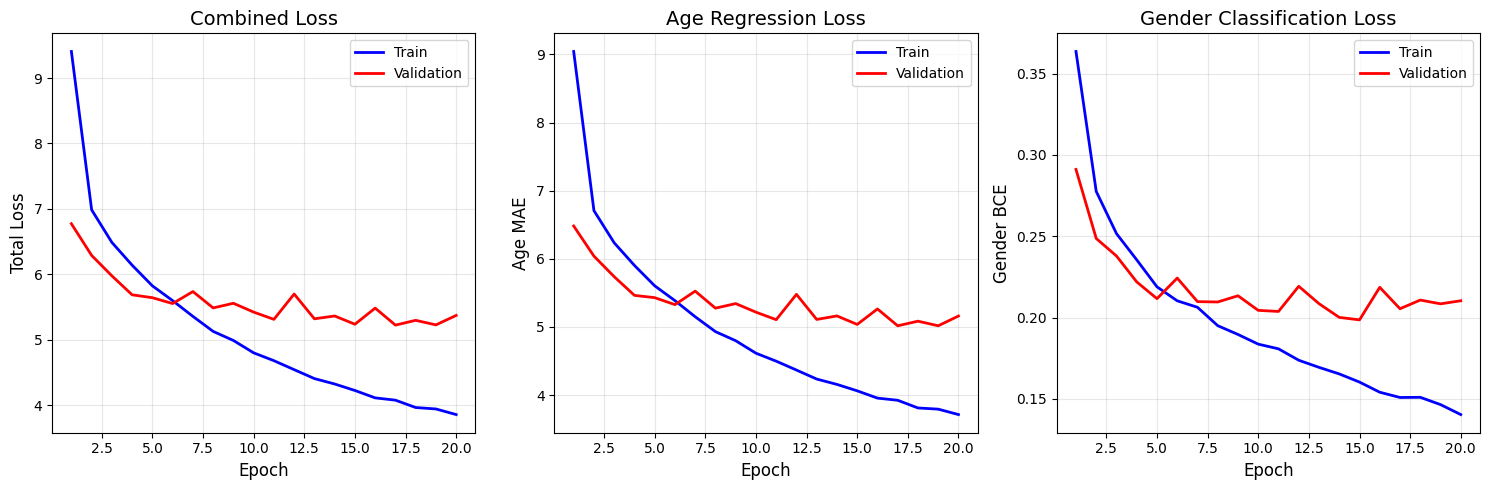

Evaluating: 100%|██████████| 225/225 [00:31<00:00,  7.03it/s]


Evaluation Results:
  Age MAE: 5.02 years
  Gender Accuracy: 0.9237 (92.37%)
Saved experiment results to c:\Users\Mark\Projects\age-gender-cnn\experiments\exp04_minimal_aug_results_20260222T154758Z.json


In [16]:
plot_training_history(
    minimal_aug_history,
    save_path=str(project_root / 'experiments' / f"{minimal_aug_config.experiment_id}_history_{run_id}.png")
)

age_preds, gender_preds, age_targets, gender_targets, metrics = evaluate_model(
    minimal_aug_model, val_loader, DEVICE
)

save_experiment_results(
    minimal_aug_config,
    metrics,
    minimal_aug_history,
    str(project_root / 'experiments' / f"{minimal_aug_config.experiment_id}_results_{run_id}.json")
)

## Experiment Summary & Comparison

In [17]:
# Load all experiment results
from utils.config import load_experiment_results

experiments = [
    'exp01_baseline',
    'exp02_age_focused',
    'exp03_conservative_lr',
    'exp04_minimal_aug'
]

results_summary = []

for exp_id in experiments:
    results_path = project_root / 'experiments' / f"{exp_id}_results_{run_id}.json"
    if results_path.exists():
        results = load_experiment_results(str(results_path))
        results_summary.append({
            'Experiment': exp_id,
            'Description': results['config'].description,
            'Age MAE': results['metrics']['age_mae'],
            'Gender Acc': results['metrics']['gender_accuracy'],
            'LR': results['config'].learning_rate,
            'Age Weight': results['config'].age_loss_weight,
            'Augmentation': results['config'].augmentation
        })

summary_df = pd.DataFrame(results_summary)
print("\n" + "="*80)
print("EXPERIMENT SUMMARY")
print("="*80)
display(summary_df)

# Identify best model
best_age_idx = summary_df['Age MAE'].idxmin()
best_gender_idx = summary_df['Gender Acc'].idxmax()

print(f"\nBest Age Performance: {summary_df.loc[best_age_idx, 'Experiment']}")
print(f"  Age MAE: {summary_df.loc[best_age_idx, 'Age MAE']:.2f} years")

print(f"\nBest Gender Performance: {summary_df.loc[best_gender_idx, 'Experiment']}")
print(f"  Gender Accuracy: {summary_df.loc[best_gender_idx, 'Gender Acc']:.4f}")


EXPERIMENT SUMMARY


,Experiment,Description,Age MAE,Gender Acc,LR,Age Weight,Augmentation
0,exp01_baseline,Baseline model with default hyperparameters,4.954776,0.926659,0.00010,1.0,full
1,exp02_age_focused,Increased age loss weight to prioritize age pe...,5.012254,0.913692,0.00010,2.0,full
2,exp03_conservative_lr,Reduced learning rate for more stable convergence,5.100276,0.917875,0.00005,1.0,full
3,exp04_minimal_aug,Minimal augmentation to test overfitting,5.016036,0.923731,0.00010,1.0,minimal



Best Age Performance: exp01_baseline
  Age MAE: 4.95 years

Best Gender Performance: exp01_baseline
  Gender Accuracy: 0.9267


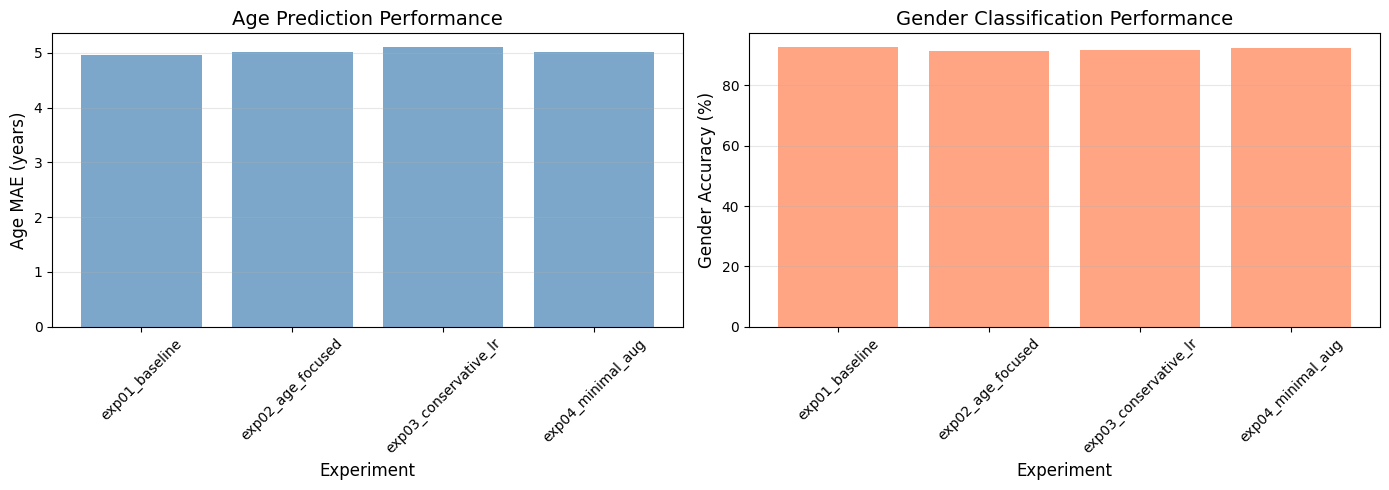

In [18]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age MAE comparison
axes[0].bar(summary_df['Experiment'], summary_df['Age MAE'], color='steelblue', alpha=0.7)
axes[0].set_xlabel('Experiment', fontsize=12)
axes[0].set_ylabel('Age MAE (years)', fontsize=12)
axes[0].set_title('Age Prediction Performance', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Gender accuracy comparison
axes[1].bar(summary_df['Experiment'], summary_df['Gender Acc'] * 100, color='coral', alpha=0.7)
axes[1].set_xlabel('Experiment', fontsize=12)
axes[1].set_ylabel('Gender Accuracy (%)', fontsize=12)
axes[1].set_title('Gender Classification Performance', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(project_root / 'experiments' / 'experiments_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Handoff Notes

**Completed**:
- ✅ Created stratified train/val/test splits (70/15/15)
- ✅ Implemented 4 experiments with different hyperparameters
- ✅ Trained models with proper checkpointing
- ✅ Generated experiment JSONs and result files
- ✅ Compared experiment performance

** Next Steps (Notebook 05)**:
- Load best model from experiments
- Comprehensive evaluation on test set
- Error analysis by demographics
- Failure case visualization
- Cross-dataset evaluation (Adience if available)
- Ethical considerations documentation

**Model Checkpoints**:
- Saved in `models/` directory
- Format: `{experiment_id}_best.pth`
- Contains: model state, optimizer state, validation loss, config

**Experiment Results**:
- Saved in `experiments/` directory
- Contains: config, final metrics, training history
- Use `load_experiment_results()` to load